# Step 6, part 1: First XGBoost model

**Boosting:** XGBoost builds small trees one after another. Each new tree focuses on the mistakes the team has made so far.
(Random Forest = **bagging**: many independent trees that vote.)

Trees don't need the Step 5 preparation:
- **Empty values:** XGBoost handles them itself.
- **Log / scaling:** not needed, because a tree only cares about the order of values.
- **One-hot:** not needed, because XGBoost reads `category` directly as a category type.

So we use the saved Parquet files with the original 9 features. **Test is not touched.**

In [33]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
val = pd.read_parquet("../data/processed/val.parquet")

features = [
    "amt", "category", "hour", "age",
    "secs_since_last", "is_first_txn",
    "card_avg_amt_before", "amt_ratio", "txn_count_24h",
]
target = "is_fraud"

X_train, y_train = train[features], train[target]
X_val, y_val = val[features], val[target]

print("Train:", X_train.shape, " Val:", X_val.shape)
print("category type:", X_train["category"].dtype)
print("Empty values left in (XGBoost handles them):", int(X_train.isna().sum().sum()))

Train: (1070966, 9)  Val: (225709, 9)
category type: category
Empty values left in (XGBoost handles them): 2901


In [3]:
# XGBoost's version of class_weight="balanced": how many normal rows per fraud row in train
n_normal = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
scale_pos_weight = n_normal / n_fraud

print(f"Normal: {n_normal:,}  Fraud: {n_fraud:,}  scale_pos_weight: {scale_pos_weight:.1f}")

Normal: 1,064,716  Fraud: 6,250  scale_pos_weight: 170.4


In [4]:
# Everything else stays at the defaults for now
xgb = XGBClassifier(
    tree_method="hist",
    enable_categorical=True,      # read category directly, no one-hot
    scale_pos_weight=scale_pos_weight,
)
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [5]:
# Fraud scores (0 to 1), not yes/no answers
train_scores = xgb.predict_proba(X_train)[:, 1]
val_scores = xgb.predict_proba(X_val)[:, 1]

train_pr_auc = average_precision_score(y_train, train_scores)
val_pr_auc = average_precision_score(y_val, val_scores)
val_roc_auc = roc_auc_score(y_val, val_scores)

print(f"Val PR-AUC:   {val_pr_auc:.4f}  (random = {y_val.mean():.4f}, baseline logistic regression = 0.2209)")
print(f"Val ROC-AUC:  {val_roc_auc:.4f}  (baseline = 0.9331)")
print(f"Train PR-AUC: {train_pr_auc:.4f}")
print(f"Gap (train - val PR-AUC): {train_pr_auc - val_pr_auc:.4f}  <- a big gap means memorising")

Val PR-AUC:   0.9390  (random = 0.0056, baseline logistic regression = 0.2209)
Val ROC-AUC:  0.9990  (baseline = 0.9331)
Train PR-AUC: 0.9901
Gap (train - val PR-AUC): 0.0511  <- a big gap means memorising


In [6]:
#Feature importance
gain_score = xgb.get_booster().get_score(importance_type="gain")

In [7]:
gain_importance = pd.Series(gain_score).sort_values(ascending=False)

In [8]:
top_5 =gain_importance.head(5)

In [9]:
top_5

amt                    5047.275391
category               1310.215088
hour                    707.684448
card_avg_amt_before     172.588364
txn_count_24h           158.224380
dtype: float64

What if test

In [10]:
card_features = [
    "secs_since_last",
    "is_first_txn",
    "card_avg_amt_before",
    "amt_ratio",
    "txn_count_24h"
]


In [13]:
features_no_card = [f for f in features if f not in card_features]
features_no_card


['amt', 'category', 'hour', 'age']

In [14]:
X_train_no_card = train[features_no_card]
X_val_no_card = val[features_no_card]

In [15]:
xgb_no_card = XGBClassifier(
    # use exactly the same settings as xgb
    tree_method=xgb.get_params()["tree_method"],
    enable_categorical=xgb.get_params()["enable_categorical"],
    scale_pos_weight=xgb.get_params()["scale_pos_weight"],
    # include the rest of your original settings unchanged
)

In [16]:
xgb_no_card.fit(X_train_no_card, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [19]:
val_fraud_scores_no_card = xgb_no_card.predict_proba(X_val_no_card)[:, 1]

In [20]:
pr_auc_no_card = average_precision_score(y_val, val_fraud_scores_no_card)

print("With card features:    0.939")
print(f"Without card features: {pr_auc_no_card:.3f}")

With card features:    0.939
Without card features: 0.907


Early Stopping

In [21]:
xgb_es = XGBClassifier(
    # Same settings as 6.1
    tree_method=xgb.get_params()["tree_method"],
    enable_categorical=xgb.get_params()["enable_categorical"],
    scale_pos_weight=xgb.get_params()["scale_pos_weight"],

    # Early stopping settings
    n_estimators=2000,
    early_stopping_rounds=50,
    eval_metric="aucpr"
)

xgb_es.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-aucpr:0.67855
[100]	validation_0-aucpr:0.93877
[135]	validation_0-aucpr:0.93654


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [22]:
#Best Iteration
best_iteration = xgb_es.best_iteration
trees_used =best_iteration+1

In [23]:
#Prediction on validation 
val_scores_es = xgb_es.predict_proba(X_val)[:, 1]
train_scores_es = xgb_es.predict_proba(X_train)[:, 1]

In [24]:
#PR_AUC
val_pr_auc_es = average_precision_score(y_val, val_scores_es)
train_pr_auc_es = average_precision_score(y_train, train_scores_es)

print("Best iteration:", best_iteration)
print("Trees used:", trees_used)
print("Val PR-AUC:", val_pr_auc_es)
print("Train PR-AUC:", train_pr_auc_es)
print("Gap:", train_pr_auc_es - val_pr_auc_es)

Best iteration: 85
Trees used: 86
Val PR-AUC: 0.9400697537633946
Train PR-AUC: 0.986691012474693
Gap: 0.04662125871129841


In [25]:
print(f"{'':25} {'6.1 (100 trees)':>18} {'6.3 (early stopping)':>23}")
print(f"{'Trees used':25} {100:>18} {trees_used:>23}")
print(f"{'Val PR-AUC':25} {0.939:>18.3f} {val_pr_auc_es:>23.3f}")
print(f"{'Train PR-AUC':25} {0.990:>18.3f} {train_pr_auc_es:>23.3f}")
print(f"{'Gap':25} {0.990 - 0.939:>18.3f} {train_pr_auc_es - val_pr_auc_es:>23.3f}")

                             6.1 (100 trees)    6.3 (early stopping)
Trees used                               100                      86
Val PR-AUC                             0.939                   0.940
Train PR-AUC                           0.990                   0.987
Gap                                    0.051                   0.047


## Step 6 part 4: XGBoost vs LightGBM

When scores are close, banks also choose on **speed** (the API must answer fast), simplicity and stability. So we measure time as well as score.

- Same 9 features, same `scale_pos_weight` (170.4), and up to 2,000 trees with early stopping of 50 rounds watching val.
- XGBoost is trained again with the 6.3 settings, only so that we can time it.
- **LightGBM needed `learning_rate=0.05`.** With its default 0.1 plus the big fraud weight, val PR-AUC jumped around and early stopping quit after 4 trees (PR-AUC 0.17). That's a stability point worth knowing.
- **Test is not touched.**

In [26]:
import time
import lightgbm as lgb
from lightgbm import LGBMClassifier

# XGBoost with the exact 6.3 settings, trained again so we can time it
xgb_timed = XGBClassifier(
    tree_method="hist",
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    n_estimators=2000,
    early_stopping_rounds=50,
    eval_metric="aucpr",
)

start = time.perf_counter()
xgb_timed.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_train_time = time.perf_counter() - start

In [27]:
# LightGBM: reads the pandas "category" column directly, like XGBoost
# learning_rate=0.05: with the default 0.1 and the big fraud weight (170), LightGBM's trees overshoot,
# val PR-AUC jumps around (0.27 -> 0.26 -> 0.40), and early stopping quits after only 4 trees (PR-AUC 0.17).
# A gentler learning rate lets the score climb smoothly.
lgbm = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,   # same 170.4 as XGBoost
    metric="average_precision",          # watch PR-AUC (and only that)
    verbose=-1,                          # hide LightGBM's info messages
)

start = time.perf_counter()
lgbm.fit(
    X_train, y_train,
    eval_X=X_val, eval_y=y_val,          # LightGBM 4.7's name for eval_set
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],   # early stopping in LightGBM = a callback
)
lgbm_train_time = time.perf_counter() - start

Training until validation scores don't improve for 50 rounds
[100]	valid_0's average_precision: 0.923527
[200]	valid_0's average_precision: 0.934352
[300]	valid_0's average_precision: 0.937481
[400]	valid_0's average_precision: 0.940153
[500]	valid_0's average_precision: 0.940212
Early stopping, best iteration is:
[471]	valid_0's average_precision: 0.941127


In [28]:
def measure(model, trees_kept, train_time):
    # Time to score all of val (this is the speed the API cares about)
    start = time.perf_counter()
    val_scores = model.predict_proba(X_val)[:, 1]
    predict_time = time.perf_counter() - start

    train_scores = model.predict_proba(X_train)[:, 1]
    return {
        "Trees kept": trees_kept,
        "Val PR-AUC": round(average_precision_score(y_val, val_scores), 4),
        "Train PR-AUC": round(average_precision_score(y_train, train_scores), 4),
        "Training time (s)": round(train_time, 1),
        "Predict all val (s)": round(predict_time, 2),
        "Per transaction (microseconds)": round(predict_time / len(X_val) * 1e6, 2),
    }

comparison = pd.DataFrame({
    "XGBoost": measure(xgb_timed, xgb_timed.best_iteration + 1, xgb_train_time),   # XGBoost counts from 0
    "LightGBM": measure(lgbm, lgbm.best_iteration_, lgbm_train_time),             # LightGBM counts from 1
}).T
comparison["Gap (train - val)"] = (comparison["Train PR-AUC"] - comparison["Val PR-AUC"]).round(4)
comparison

,Trees kept,Val PR-AUC,Train PR-AUC,Training time (s),Predict all val (s),Per transaction (microseconds),Gap (train - val)
XGBoost,86.0,0.9401,0.9867,25.3,0.22,0.98,0.0466
LightGBM,471.0,0.9411,0.9871,25.2,1.91,8.48,0.0460


In [29]:
cutoffs = [0.5, 0.7, 0.9, 0.95, 0.99]


In [30]:
all_val_frauds = y_val.sum()

rows = []

for cutoff in cutoffs:
    # Flag transactions whose fraud score is at least the cutoff
    flagged = val_scores_es >= cutoff

    # Count flagged transactions
    flagged_count = flagged.sum()

    # Count frauds correctly caught
    frauds_caught = ((flagged) & (y_val == 1)).sum()

    # Count legitimate transactions incorrectly flagged
    false_alarms = ((flagged) & (y_val == 0)).sum()

    # Calculate recall and precision
    recall = frauds_caught / all_val_frauds
    precision = frauds_caught / flagged_count if flagged_count > 0 else 0

    rows.append({
        "cutoff": cutoff,
        "flagged": flagged_count,
        "frauds_caught": frauds_caught,
        "false_alarms": false_alarms,
        "recall": recall,
        "precision": precision
    })

# Turn the list of dictionaries into a table
threshold_summary = pd.DataFrame(rows)

threshold_summary

,cutoff,flagged,frauds_caught,false_alarms,recall,precision
0,0.50,2350,1206,1144,0.960191,0.513191
1,0.70,1919,1186,733,0.944268,0.618030
2,0.90,1447,1135,312,0.903662,0.784381
3,0.95,1297,1102,195,0.877389,0.849653
4,0.99,1059,1008,51,0.802548,0.951841


In [31]:
# 1. Get the real transaction amounts from the validation set
amounts = X_val["amt"]


In [34]:
# 2. Create cutoffs from 0.50 to 0.99 in steps of 0.01
cutoffs = np.round(np.arange(0.50, 1.00, 0.01), 2)

In [35]:
#Calculate the total number of frauds' dollar amount
no_model_cost = amounts[y_val == 1].sum()

In [36]:

# 4. Store one result row for each cutoff
rows = []

for cutoff in cutoffs:

    # Transactions with a score >= cutoff are flagged
    flagged = val_scores_es >= cutoff

    # Number of alerts
    alerts = flagged.sum()

    # Each alert costs $10
    alerts_cost = alerts * 10

    # Fraud transactions that were NOT flagged
    missed = (~flagged) & (y_val == 1)

    # Number of missed frauds
    missed_frauds = missed.sum()

    # Dollar cost of the missed frauds
    missed_cost = amounts[missed].sum()

    # Total cost = cost of alerts + cost of missed fraud
    total_cost = alerts_cost + missed_cost

    # Save this cutoff's results
    rows.append({
        "cutoff": cutoff,
        "alerts": alerts,
        "alerts_cost": alerts_cost,
        "missed_frauds": missed_frauds,
        "missed_cost": missed_cost,
        "total_cost": total_cost
    })

In [38]:
# 5. Turn the rows into a pandas table
cost_table = pd.DataFrame(rows)

cost_table
#Find the cheapest cutoff
# Position of the row with the smallest total cost
cheapest_position = cost_table["total_cost"].idxmin()


In [39]:
cheapest = cost_table.loc[cheapest_position]

cheapest

cutoff               0.59
alerts            2144.00
alerts_cost      21440.00
missed_frauds       60.00
missed_cost      13770.72
total_cost       35210.72
Name: 9, dtype: float64

In [40]:
cost_090 = cost_table[cost_table["cutoff"] == 0.90].iloc[0]

cost_090


cutoff               0.90
alerts            1447.00
alerts_cost      14470.00
missed_frauds      121.00
missed_cost      29936.23
total_cost       44406.23
Name: 40, dtype: float64

In [41]:
# Savings from using the model instead of flagging nothing
model_savings = no_model_cost - cheapest["total_cost"]

# Savings from using the cheapest cutoff instead of 0.90
savings_vs_090 = cost_090["total_cost"] - cheapest["total_cost"]

print("No-model cost:", no_model_cost)
print("Cheapest cutoff:", cheapest["cutoff"])
print("Cheapest total cost:", cheapest["total_cost"])
print("Alerts at cheapest cutoff:", cheapest["alerts"])
print("Cost at 0.90:", cost_090["total_cost"])
print("Savings vs no model:", model_savings)
print("Savings vs 0.90:", savings_vs_090)

No-model cost: 671623.3899999999
Cheapest cutoff: 0.59
Cheapest total cost: 35210.72
Alerts at cheapest cutoff: 2144.0
Cost at 0.90: 44406.23
Savings vs no model: 636412.6699999999
Savings vs 0.90: 9195.510000000002


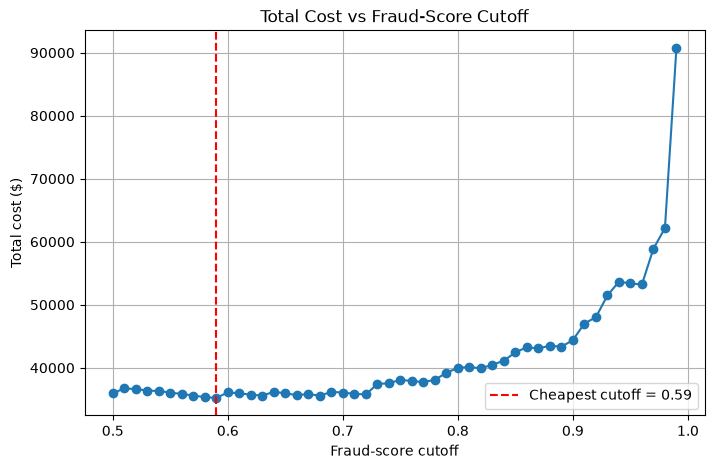

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    cost_table["cutoff"],
    cost_table["total_cost"],
    marker="o"
)

plt.axvline(
    cheapest["cutoff"],
    color="red",
    linestyle="--",
    label=f"Cheapest cutoff = {cheapest['cutoff']:.2f}"
)

plt.xlabel("Fraud-score cutoff")
plt.ylabel("Total cost ($)")
plt.title("Total Cost vs Fraud-Score Cutoff")
plt.legend()
plt.grid(True)

plt.show()

## Step 7.3: The final exam (test, opened once)

**Rule:** this runs **once**. Whatever the result, the model and the cutoff (0.90) are **not changed** afterwards. Changing things after seeing test would turn test into just another validation set, and the honest score would be lost.

### My prediction (written BEFORE running the cells below)

Will test PR-AUC be higher or lower than val's 0.940? Hint: test's fraud rate is lower (0.386% vs 0.556%).

**Prediction:** _write here: higher or lower, and why_

In [43]:
# Opening test: the champion model (xgb_es) only scores it. Nothing is trained or tuned on test.
test = pd.read_parquet("../data/processed/test.parquet")
X_test, y_test = test[features], test[target]

test_scores = xgb_es.predict_proba(X_test)[:, 1]

In [44]:
def final_results(y, scores, amounts, dates, cutoff=0.90):
    flagged = scores >= cutoff
    caught = (flagged & (y == 1)).sum()
    missed = (~flagged) & (y == 1)
    alerts = flagged.sum()
    total_cost = alerts * 10 + amounts[missed].sum()

    # Months covered, from the real dates (val is about 3, test about 6.3)
    months = (dates.max() - dates.min()).days / 30.44

    return {
        "Fraud rate %": round(y.mean() * 100, 3),
        "PR-AUC": round(average_precision_score(y, scores), 4),
        "ROC-AUC": round(roc_auc_score(y, scores), 4),
        "Frauds": int(y.sum()),
        "Alerts": int(alerts),
        "Frauds caught": int(caught),
        "Recall %": round(caught / y.sum() * 100, 1),
        "Precision %": round(caught / alerts * 100, 1),
        "False alarms": int(alerts - caught),
        "Total cost $": round(total_cost),
        "Months": round(months, 1),
        "Alerts per month": round(alerts / months),
        "Cost per month $": round(total_cost / months),
    }

In [45]:
final_exam = pd.DataFrame({
    "Val (3 months)": final_results(y_val, val_scores_es, X_val["amt"], val["trans_date_trans_time"]),
    "Test (6 months)": final_results(y_test, test_scores, X_test["amt"], test["trans_date_trans_time"]),
})
final_exam

,Val (3 months),Test (6 months)
Fraud rate %,0.5560,0.3860
PR-AUC,0.9401,0.9058
ROC-AUC,0.9991,0.9981
Frauds,1256.0000,2145.0000
Alerts,1447.0000,2576.0000
Frauds caught,1135.0000,1878.0000
Recall %,90.4000,87.6000
Precision %,78.4000,72.9000
False alarms,312.0000,698.0000
Total cost $,44406.0000,85477.0000
